# 02 — Análise Exploratória

**Objetivo:** entender o comportamento histórico do USD/BRL entre 2010 e 2026 — evolução, máximas, mínimas, retornos e volatilidade.

**Entradas:** `data/processed/dataset_analitico.csv`  
**Saídas:** gráficos em `reports/figures/`

---

## 0. Setup

In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path('..') / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

from load import load_dataset
from indicators import (
    describe_series,
    summary_by_default_periods,
    calc_returns,
    find_extremes,
    calc_cumulative_return,
    high_volatility_periods,
)
from plots import (
    plot_usd_brl_history,
    plot_volatility,
    plot_stats_by_period,
    set_style,
)

pd.set_option('display.float_format', '{:.4f}'.format)
set_style()

df = load_dataset()
print(f'Dataset carregado: {df.shape[0]} meses × {df.shape[1]} colunas')
print(f'Período: {df.index.min().date()} → {df.index.max().date()}')

2026-04-11 00:05:04 | INFO     | load | Dataset carregado: 175 meses × 12 colunas


Dataset carregado: 175 meses × 12 colunas
Período: 2010-01-31 → 2024-07-31


## 1. Evolução histórica do USD/BRL

2026-04-11 00:05:08 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\01_usd_brl_historico.png


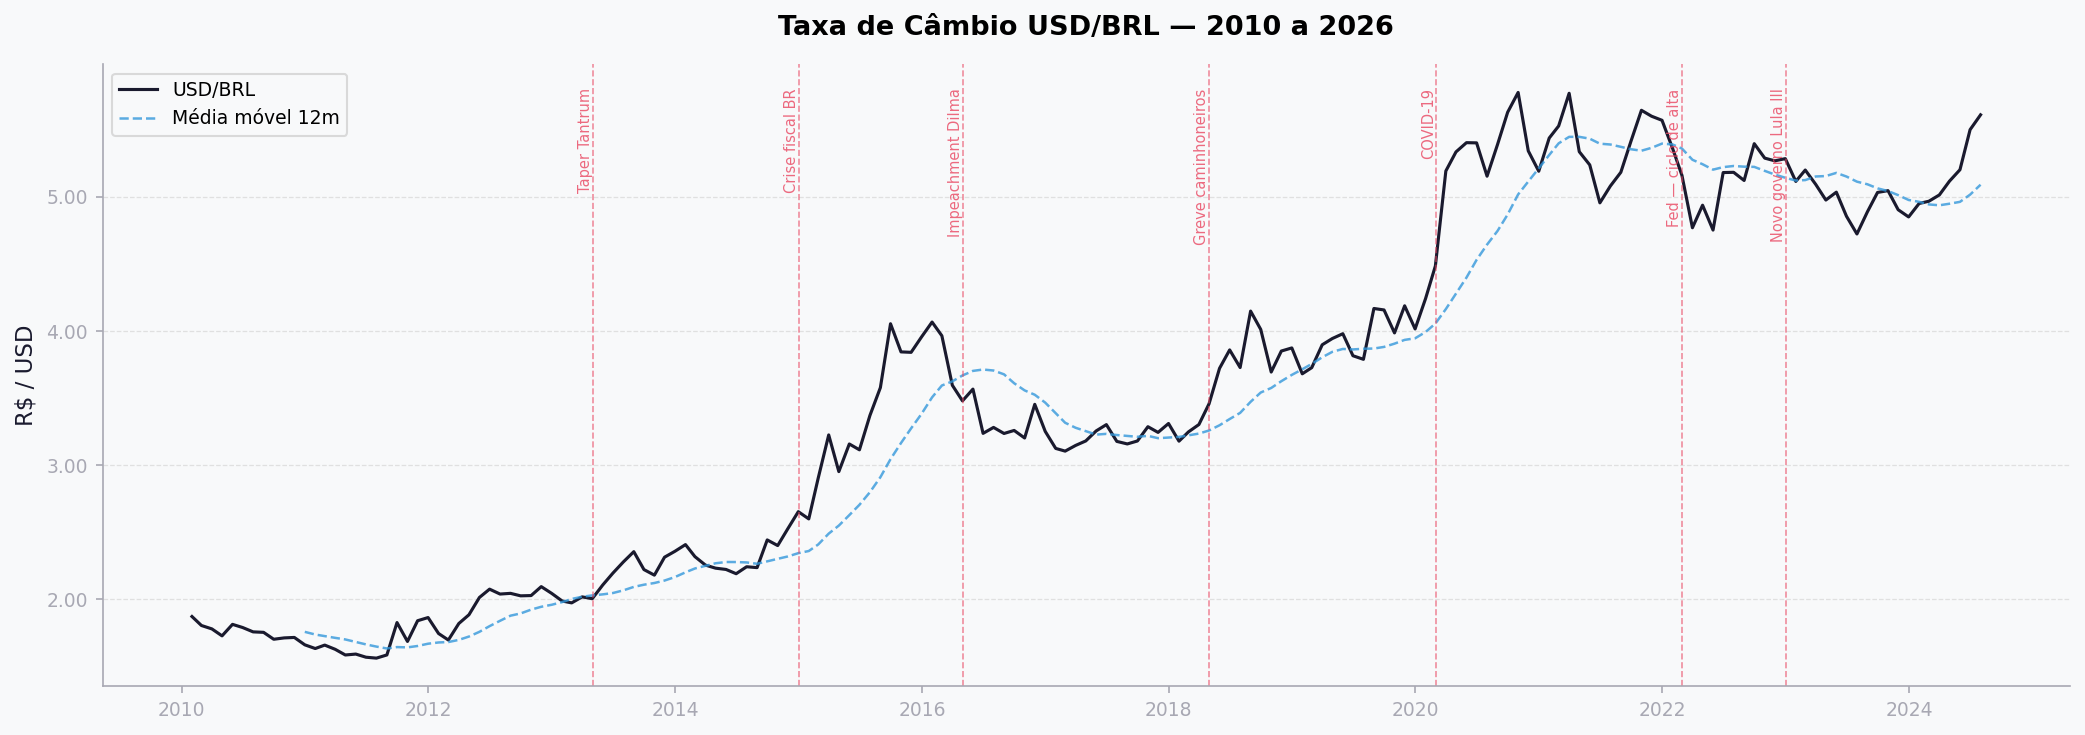

In [4]:
fig = plot_usd_brl_history(df, show_events=True)
plt.show()

## 2. Estatísticas descritivas gerais

In [5]:
stats = describe_series(df, 'usd_brl')
print('USD/BRL — Estatísticas descritivas (2010–2026)')
print('=' * 45)
for k, v in stats.items():
    print(f'  {k:<15} {v:.4f}')

USD/BRL — Estatísticas descritivas (2010–2026)
  count           175.0000
  mean            3.5201
  std             1.3406
  min             1.5628
  25%             2.2093
  50%             3.3708
  75%             4.9527
  max             5.7778
  skewness        0.0914
  kurtosis        -1.3862


## 3. Análise por subperíodo

In [6]:
summary = summary_by_default_periods(df, 'usd_brl')
summary.round(4)

,início,fim,média,mediana,mínimo,máximo,desvio_padrão,variação_%,n_meses
período,,,,,,,,,
Lula II / Dilma I (2010–2014),2010-01-01,2014-12-31,1.9803,1.9970,1.5628,2.6541,0.2792,41.7107,60
Crise fiscal / Temer (2015–2018),2015-01-01,2018-12-31,3.4326,3.2950,2.6002,4.1486,0.3517,48.9962,48
Bolsonaro / COVID (2019–2022),2019-01-01,2022-12-31,4.9242,5.1828,3.6814,5.7778,0.6412,43.5486,48
Lula III (2023–2026),2023-01-01,2026-12-31,5.0569,5.0328,4.7233,5.6111,0.2146,9.7011,19


2026-04-11 00:05:20 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\05_barras_média_por_periodo.png


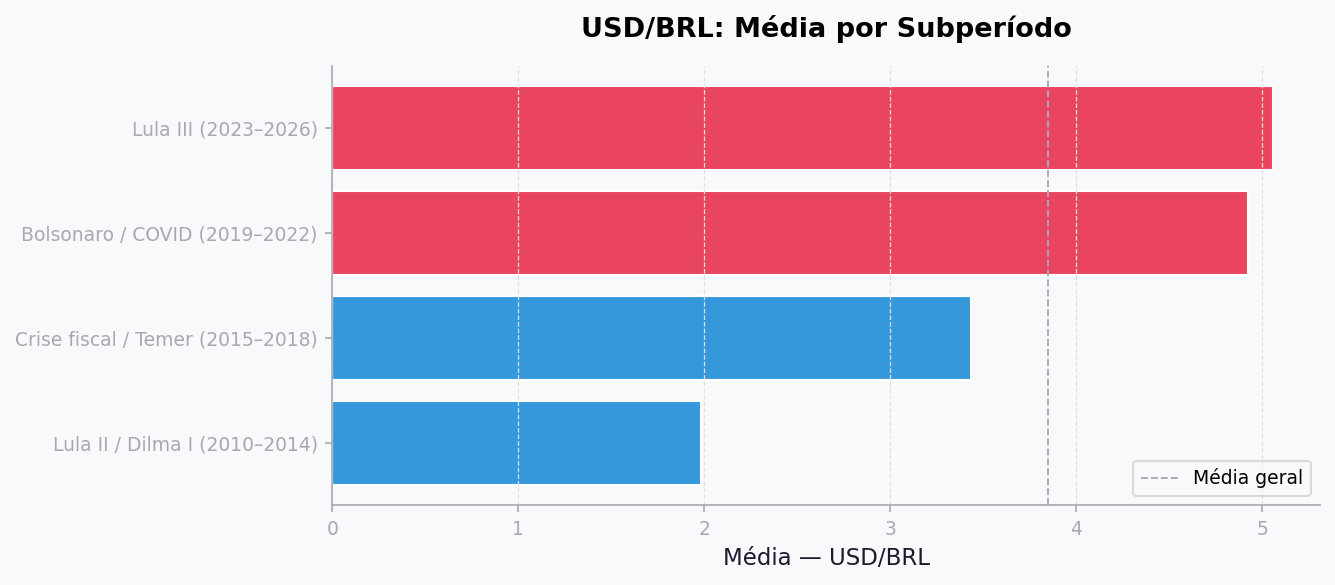

In [7]:
fig = plot_stats_by_period(summary, metric='média', col_label='USD/BRL')
plt.show()

2026-04-11 00:05:20 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\05_barras_variação_%_por_periodo.png


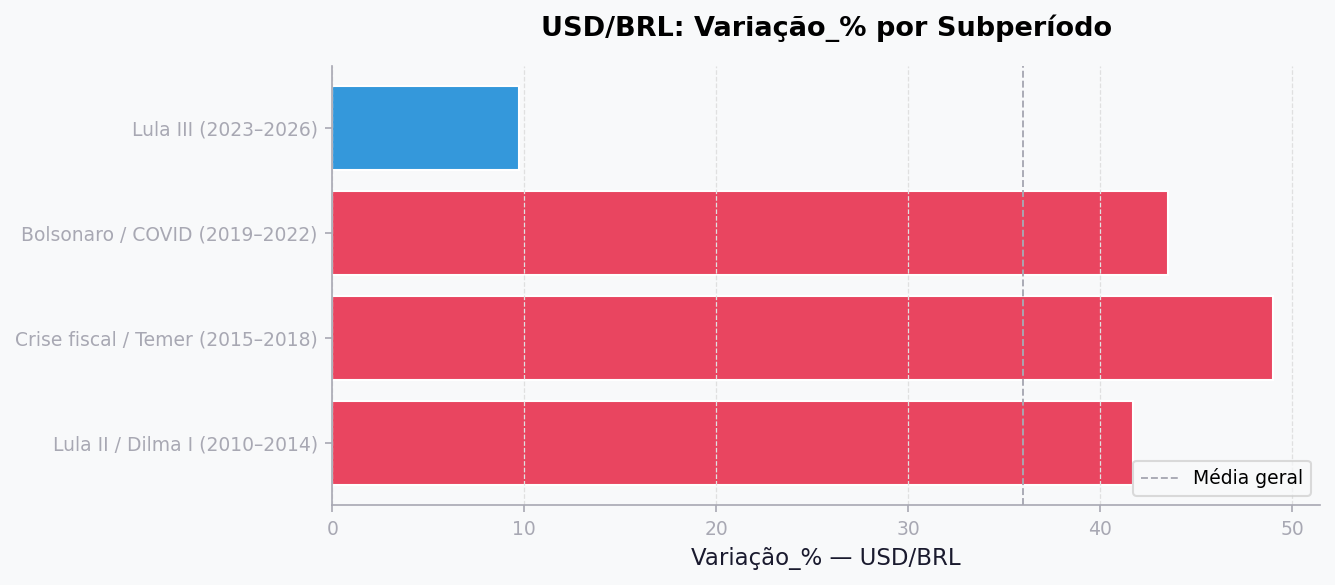

In [8]:
fig = plot_stats_by_period(summary, metric='variação_%', col_label='USD/BRL')
plt.show()

## 4. Máximas e mínimas históricas

In [9]:
extremos = find_extremes(df['usd_brl'], n=5)
print('Top 5 máximas e mínimas históricas do USD/BRL')
extremos

Top 5 máximas e mínimas históricas do USD/BRL


,data,valor,tipo
0,2011-04-30,1.5863,mínima
1,2011-05-31,1.5930,mínima
2,2011-06-30,1.5697,mínima
3,2011-07-31,1.5628,mínima
4,2011-08-31,1.5865,mínima
5,2020-09-30,5.6305,máxima
6,2020-10-31,5.7778,máxima
7,2021-03-31,5.7716,máxima
8,2021-10-31,5.6449,máxima
9,2024-07-31,5.6111,máxima


## 5. Retornos mensais

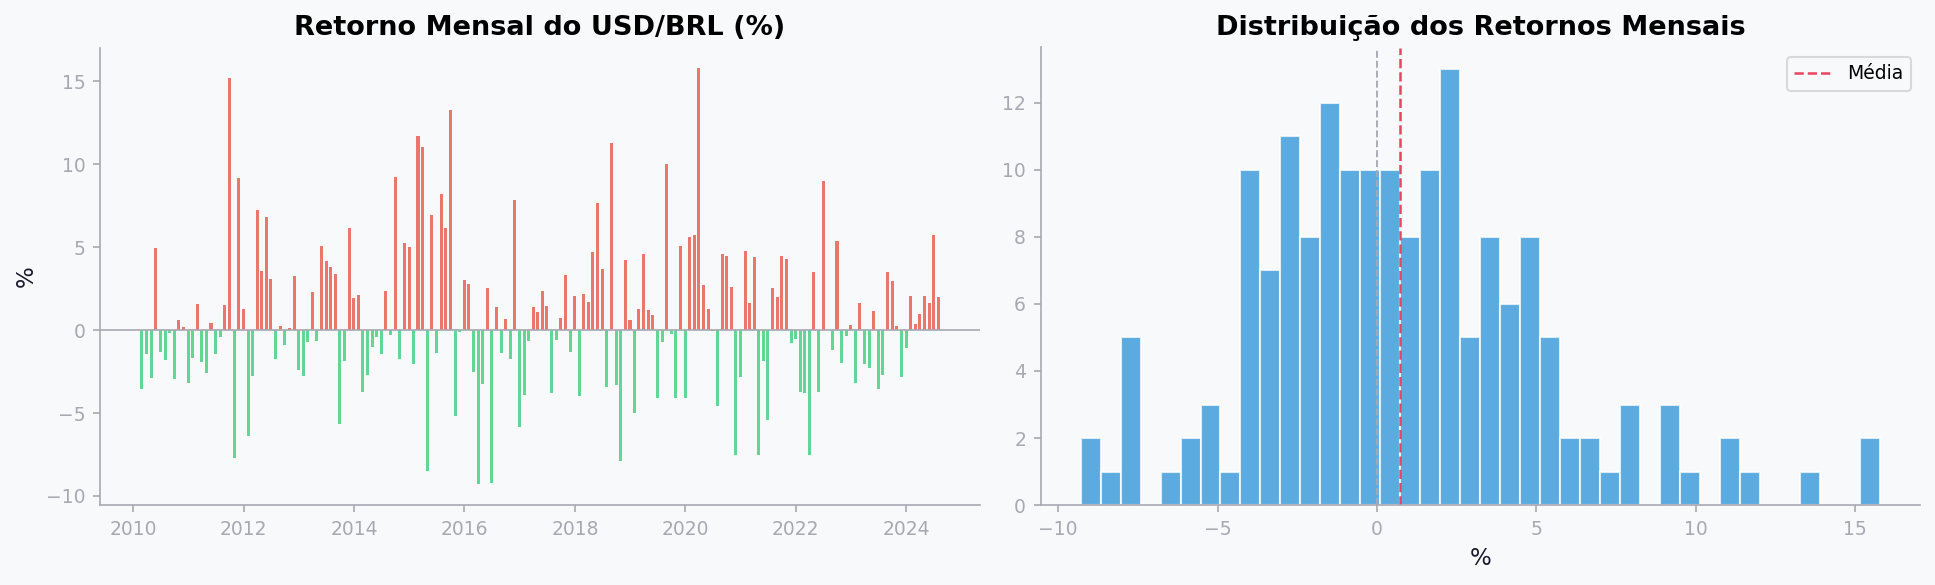


Retorno médio mensal : 0.732%
Desvio padrão        : 4.519%
Meses de alta (USD)  : 93 (53.1%)
Meses de queda (USD) : 81 (46.3%)


In [11]:
retornos = calc_returns(df['usd_brl'])
retornos_pct = retornos * 100

set_style()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# série temporal dos retornos
ret_x = retornos.index
ret_y = retornos_pct.to_numpy(dtype=float)
axes[0].bar(
    ret_x,
    ret_y,
    color=['#e74c3c' if v > 0 else '#2ecc71' for v in ret_y],
    alpha=0.75,
    width=20,
    align='center',
)
axes[0].axhline(0, color='#a8a8b3', linewidth=0.8)
axes[0].set_title('Retorno Mensal do USD/BRL (%)', fontweight='bold')
axes[0].set_ylabel('%')

# distribuição dos retornos
hist_vals = retornos_pct.dropna().to_numpy(dtype=float)
axes[1].hist(
    hist_vals,
    bins=40,
    color='#3498db',
    edgecolor='white',
    alpha=0.8,
 )
axes[1].axvline(0, color='#a8a8b3', linewidth=0.9, linestyle='--')
axes[1].axvline(
    hist_vals.mean(),
    color='#e94560',
    linewidth=1.2,
    linestyle='--',
    label='Média',
)
axes[1].set_title('Distribuição dos Retornos Mensais', fontweight='bold')
axes[1].set_xlabel('%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/02_retornos_mensais.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nRetorno médio mensal : {retornos.mean()*100:.3f}%')
print(f'Desvio padrão        : {retornos.std()*100:.3f}%')
print(f'Meses de alta (USD)  : {(retornos > 0).sum()} ({(retornos > 0).mean()*100:.1f}%)')
print(f'Meses de queda (USD) : {(retornos < 0).sum()} ({(retornos < 0).mean()*100:.1f}%)')

## 6. Volatilidade rolling

2026-04-11 00:05:53 | INFO     | plots | Figura salva: C:\Users\edupe\usd-brl-analysis-2010-2026\reports\figures\02_volatilidade_rolling.png


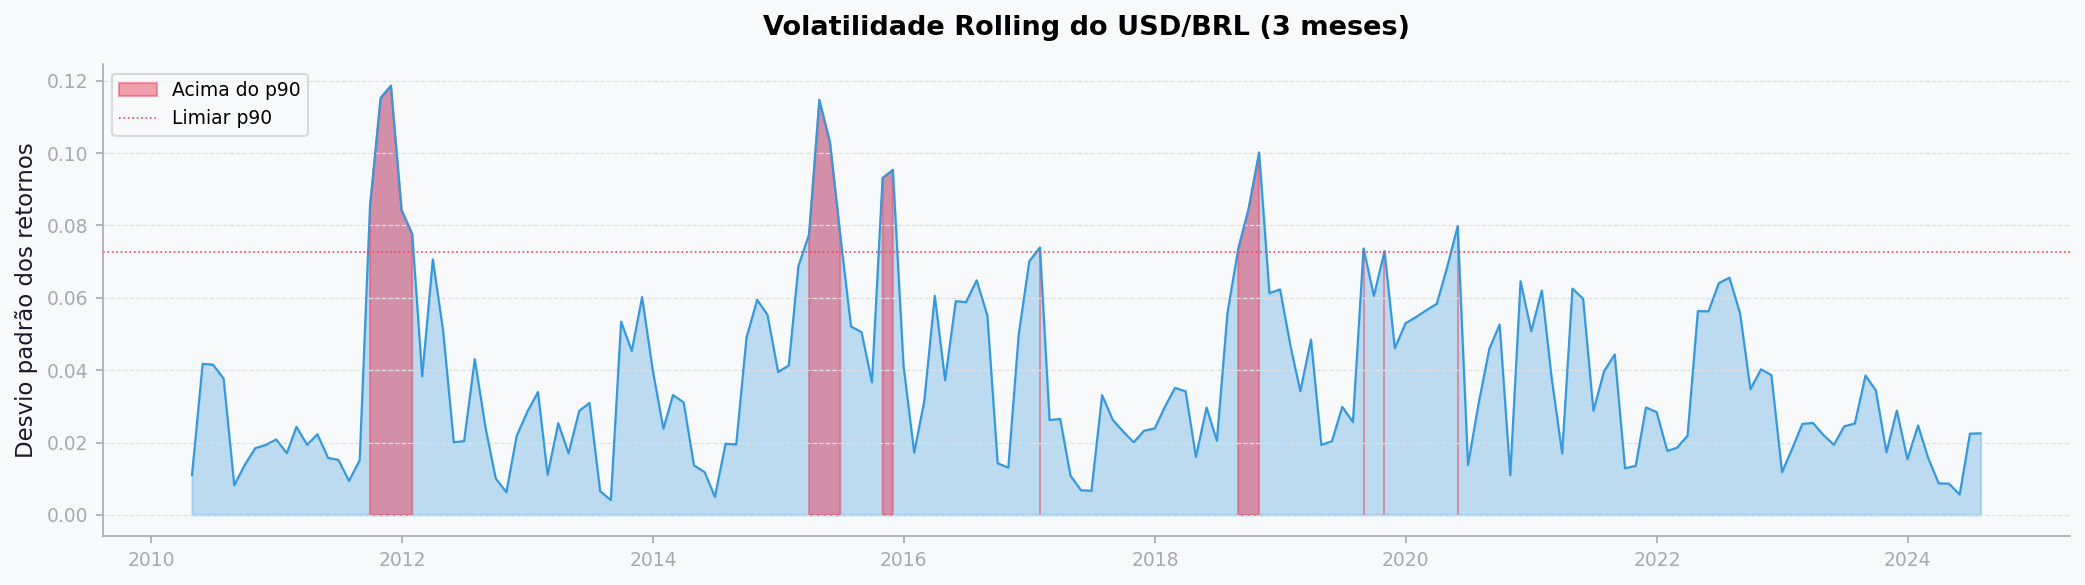

In [12]:
fig = plot_volatility(df, vol_col='usd_brl_volatilidade', pct_threshold=90)
plt.show()

In [13]:
# períodos de alta volatilidade (acima do percentil 90)
alta_vol = high_volatility_periods(df['usd_brl_volatilidade'], percentile=90)
periodos_estresse = df[alta_vol][['usd_brl', 'usd_brl_volatilidade']]

print(f'Meses com alta volatilidade (p90): {alta_vol.sum()}')
print()
periodos_estresse.sort_values('usd_brl_volatilidade', ascending=False).head(10)

Meses com alta volatilidade (p90): 18



,usd_brl,usd_brl_volatilidade
data,,
2011-11-30,1.8415,0.1186
2011-10-31,1.6871,0.1152
2015-04-30,2.9527,0.1147
2015-05-31,3.1584,0.1030
2018-10-31,3.6946,0.1002
2015-11-30,3.8414,0.0954
2015-10-31,3.8447,0.0931
2011-09-30,1.8277,0.0852
2018-09-30,4.0120,0.0845


## 7. Depreciação acumulada do real

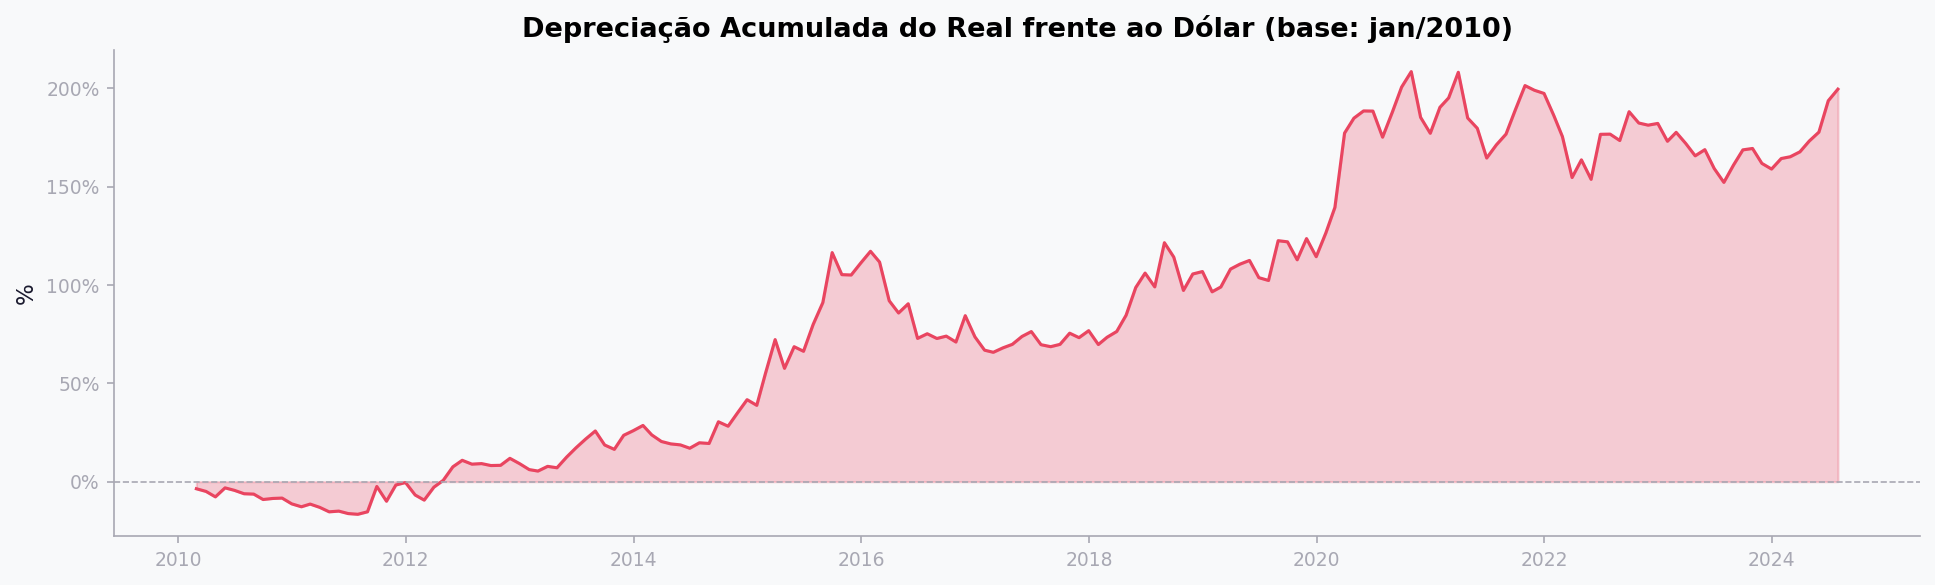

Depreciação acumulada total (2010–2026): 199.6%


In [14]:
acumulado = calc_cumulative_return(retornos * 100)

set_style()
fig, ax = plt.subplots(figsize=(13, 4))
ac_x = acumulado.index.to_numpy()
ac_y = acumulado.to_numpy(dtype=float)
ax.fill_between(ac_x, ac_y, alpha=0.25, color='#e94560')
ax.plot(ac_x, ac_y, color='#e94560', linewidth=1.5)
ax.axhline(0, color='#a8a8b3', linewidth=0.8, linestyle='--')
ax.set_title('Depreciação Acumulada do Real frente ao Dólar (base: jan/2010)', fontweight='bold')
ax.set_ylabel('%')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('../reports/figures/02_depreciacao_acumulada.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Depreciação acumulada total (2010–2026): {acumulado.iloc[-1]:.1f}%')

## 8. Conclusão

**Principais achados desta etapa:**

- *[Preencher após execução com os números reais do dataset]*
- Média histórica do USD/BRL no período
- Subperíodo com maior valorização do dólar
- Meses de maior estresse cambial
- Depreciação acumulada total do real

Próximo passo: **Notebook 03 — Análise Macroeconômica**.